# Tải model MiDas v2.1 Small (.pth)

In [4]:
import os
import torch

print("Đang tải mô hình MiDaS v2.1 Small gốc...")
model = torch.hub.load("intel-isl/MiDaS", "MiDaS_small", pretrained=True)
model.eval()

save_path = os.path.join(os.getcwd(), "midas_v21_small.pth")
torch.save(model.state_dict(), save_path)
print(f"Đã lưu mô hình vào: {save_path}")

Đang tải mô hình MiDaS v2.1 Small gốc...


Using cache found in C:\Users\dquan/.cache\torch\hub\intel-isl_MiDaS_master
d:\UAV_Simulation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\UAV_Simulation\.venv\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to C:\Users\dquan/.cache\torch\hub\master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to C:\Users\dquan/.cache\torch\hub\checkpoints\tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to C:\Users\dquan/.cache\torch\hub\checkpoints\midas_v21_small_256.pt


100.0%


Đã lưu mô hình vào: d:\UAV_Simulation\midas_v21_small.pth


# Import video MP4, ảnh và Resize

In [1]:
#Import video moving_cars.mp4
import cv2
cap = cv2.VideoCapture("moving_cars.mp4")
# Resize video to 256x256
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 256)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 256)
# Get video properties
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))


Resized image shape: (256, 256, 3)


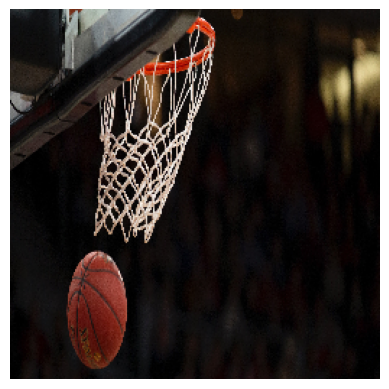

In [4]:
# Import image basketball.jpg and resize to 256x256
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("basketball.jpg")
img_resized = cv2.resize(img, (256, 256))
print("Resized image shape:", img_resized.shape)

plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Đưa ảnh vào MiDas và xuất ra chỉ số Depth

Depth map shape: (256, 256)
Depth map (5x5 đầu tiên):
[[685.229   689.68024 694.7025  689.2244  680.6865 ]
 [692.6577  664.4677  664.03235 657.1944  659.3461 ]
 [686.196   670.4598  659.8254  660.88214 659.71796]
 [682.3044  670.75256 657.9671  656.2824  655.2499 ]
 [677.7554  667.1477  662.0833  658.7504  657.20087]]
Min depth: 38.174312591552734
Max depth: 1055.1116943359375
Mean depth: 273.898193359375
Farthest point (row, col, depth): (238, 71) 1055.1116943359375
Nearest point (row, col, depth): (35, 254) 38.174312591552734


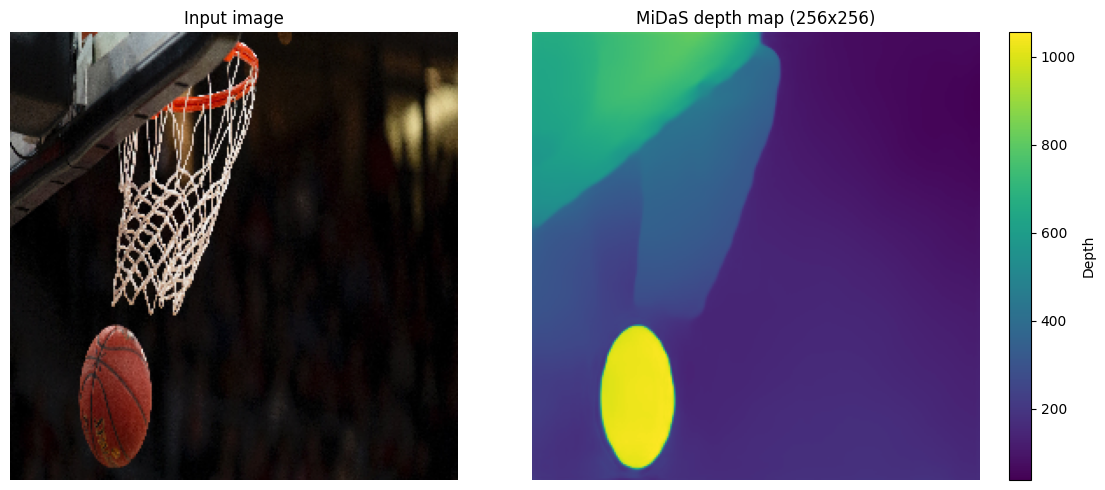

In [ ]:
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from torchvision import transforms

# Load model weights from the saved .pth file
model_path = "midas_v21_small.pth"

# Load MiDaS small architecture
model = torch.hub.load("intel-isl/MiDaS", "MiDaS_small", pretrained=False)
model.load_state_dict(torch.load(model_path, map_location="cpu"))
model.eval()

# Preprocess for MiDaS small
midas_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Convert resized image to RGB and prepare input
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
input_tensor = midas_transforms(img_rgb).unsqueeze(0)

with torch.no_grad():
    prediction = model(input_tensor)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img_resized.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze().cpu()

# Convert to numpy array with shape (256, 256)
depth_map = prediction.numpy().astype(np.float32)

print("Depth map shape:", depth_map.shape)
print("Depth map (5x5 đầu tiên):")
print(depth_map[:5, :5])
print("Min depth:", float(depth_map.min()))
print("Max depth:", float(depth_map.max()))
print("Mean depth:", float(depth_map.mean()))

# Find nearest and farthest points
farthest_idx = np.unravel_index(np.argmax(depth_map), depth_map.shape)
nearest_idx = np.unravel_index(np.argmin(depth_map), depth_map.shape)
print("Farthest point (row, col, depth):", farthest_idx, float(depth_map[farthest_idx]))
print("Nearest point (row, col, depth):", nearest_idx, float(depth_map[nearest_idx]))

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Input image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(depth_map, cmap="viridis")
plt.colorbar(label="Depth")
plt.title("MiDaS depth map (256x256)")
plt.axis("off")
plt.tight_layout()
plt.show()
